In [1]:
# ====================
# 📊 Customer Churn — Exploratory Data Analysis (EDA)
# ====================
# Author: Alee Chihaoui
# Date: June 2026

# Standard data science imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for prettier output
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)
sns.set_style("whitegrid")  # Clean seaborn style
plt.rcParams['figure.figsize'] = (10, 6)  # Default figure size

# Display all outputs in a cell (not just the last one)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print("📦 Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


📦 Libraries loaded successfully
Pandas version: 2.2.0
NumPy version: 1.26.0


In [2]:
# ====================
# 📥 Load the dataset
# ====================

# Path to the raw data file (relative to notebook location)
DATA_PATH = "../data/raw/telco_churn.csv"

# Load with pandas
df = pd.read_csv(DATA_PATH)

# Confirm it loaded
print(f"✅ Dataset loaded successfully")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully
📊 Shape: 7,043 rows × 21 columns


In [3]:
# ====================
# 👀 First glimpse of the data
# ====================

# Show the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ====================
# 📋 What columns do we have?
# ====================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# ====================
# 🔍 Investigate TotalCharges
# ====================

# What does TotalCharges look like?
print("First 5 values of TotalCharges:")
print(df['TotalCharges'].head())

print("\n" + "="*50)
print("Trying to convert TotalCharges to numeric...")

# Try to convert to float (errors='coerce' turns failures into NaN)
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# How many values FAILED to convert?
n_failed = df['TotalCharges_numeric'].isna().sum()
print(f"\n❌ Number of values that couldn't be converted: {n_failed}")
print(f"📊 That's {n_failed/len(df)*100:.2f}% of the dataset")

First 5 values of TotalCharges:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

Trying to convert TotalCharges to numeric...

❌ Number of values that couldn't be converted: 11
📊 That's 0.16% of the dataset


In [6]:
# Show the rows that have problematic TotalCharges
problematic_rows = df[df['TotalCharges_numeric'].isna()]
print(f"Found {len(problematic_rows)} problematic rows:\n")

# Display some key columns to understand WHY they're broken
problematic_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Found 11 problematic rows:



,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
# ====================
# 🧹 Clean TotalCharges
# ====================

# Step 1: Convert to numeric (this creates NaN for the 11 problematic values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Fill the NaN values with 0 (new customers = no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Drop our temporary investigation column
df = df.drop(columns=['TotalCharges_numeric'])

# Step 4: Verify the fix worked
print("✅ TotalCharges cleaned!")
print(f"📊 New dtype: {df['TotalCharges'].dtype}")
print(f"❌ Remaining NaN values: {df['TotalCharges'].isna().sum()}")
print(f"\nVerification — the 11 previously broken rows now show:")

# Show the same 11 rows again to confirm
df.loc[[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], 
       ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

✅ TotalCharges cleaned!
📊 New dtype: float64
❌ Remaining NaN values: 0

Verification — the 11 previously broken rows now show:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [8]:
# ====================
# 🔎 Final data quality check
# ====================

# Are there any other missing values we missed?
print("Missing values per column:")
print(df.isna().sum())

print("\n" + "="*50)
print("\n📊 Updated column types:")
print(df.dtypes)

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


📊 Updated column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     obj

In [9]:
# ====================
# 🎯 Target variable distribution — Version 1: Basic
# ====================

# Count how many Yes vs No
churn_counts = df['Churn'].value_counts()
print("Churn distribution:")
print(churn_counts)
print()
print("Churn rate (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<Axes: xlabel='Churn'>

Text(0, 5224, '5,174\n(73.5%)')

Text(1, 1919, '1,869\n(26.5%)')

Text(0.5, 1.0, 'Customer Churn Distribution')

Text(0.5, 0, 'Churn Status')

Text(0, 0.5, 'Number of Customers')

[Text(0, 0, 'Stayed'), Text(1, 0, 'Churned')]

Text(0.98, 0.95, 'Total: 7,043 customers')

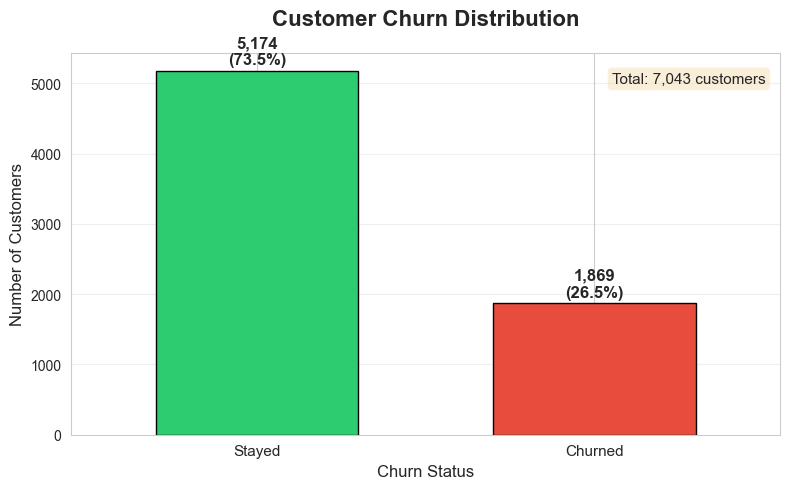

✅ Chart saved to reports/figures/01_churn_distribution.png


In [10]:
# ====================
# 🎯 Target variable distribution — Version 2: Bar chart
# ====================

fig, ax = plt.subplots(figsize=(8, 5))

# Create the bar chart
churn_counts.plot(kind='bar', 
                  ax=ax, 
                  color=['#2ecc71', '#e74c3c'],  # Green for stayers, red for churners
                  edgecolor='black',
                  width=0.6)

# Add value labels on top of each bar
for i, value in enumerate(churn_counts.values):
    percentage = value / len(df) * 100
    ax.text(i, value + 50, f'{value:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Beautify
ax.set_title('Customer Churn Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Churn Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Stayed', 'Churned'], rotation=0, fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add total customers annotation
ax.text(0.98, 0.95, f'Total: {len(df):,} customers', 
        transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/figures/01_churn_distribution.png")

<Axes: xlabel='Churn'>

Text(0, 5224, '5,174\n(73.5%)')

Text(1, 1919, '1,869\n(26.5%)')

Text(0.5, 1.0, 'Customer Count by Churn Status')

Text(0.5, 0, '')

Text(0, 0.5, 'Number of Customers')

[Text(0, 0, 'Stayed'), Text(1, 0, 'Churned')]

Text(0.5, 1.0, 'Churn Rate Proportion')

Text(0.5, 1.02, '🎯 Target Variable Analysis: Customer Churn')

C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\3590352863.py:48: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\3590352863.py:49: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig('../reports/figures/02_churn_distribution_dashboard.png',
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


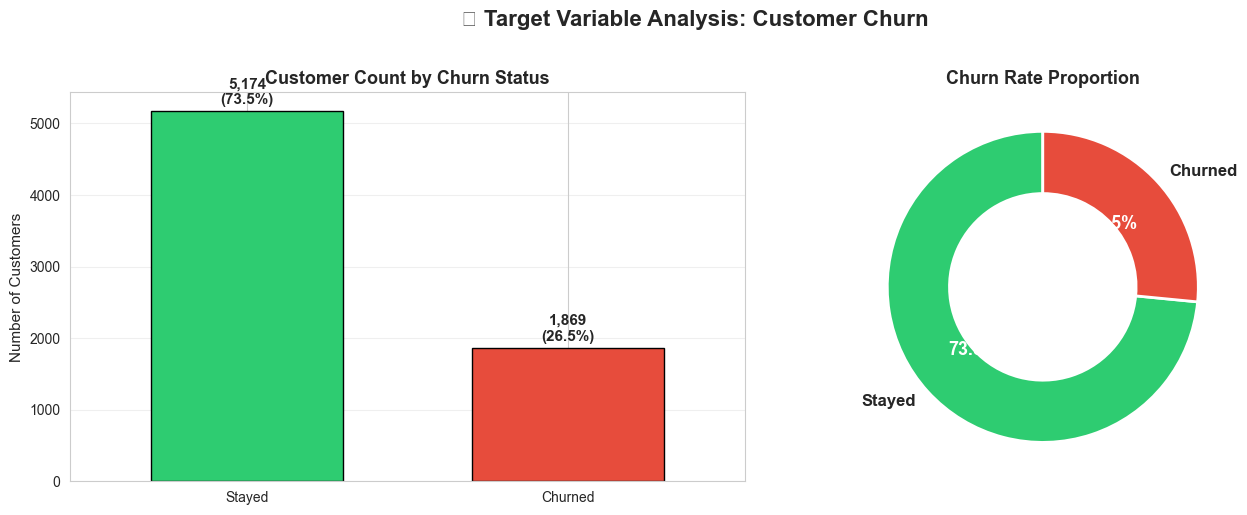


📊 KEY INSIGHTS
Total customers in dataset: 7,043
Customers who stayed:       5,174 (73.5%)
Customers who churned:      1,869 (26.5%)

💡 Churn rate of 26.5% is HIGH for telecom industry
   (industry average is ~10-15%). This represents a real business problem.

⚠️  Class imbalance ratio: 2.8:1
   → We'll need to handle this during model training.


In [11]:
# ====================
# 🎯 Target variable distribution — Version 3: Dashboard-style
# ====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === LEFT: Bar chart ===
churn_counts.plot(kind='bar', 
                  ax=axes[0], 
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='black', 
                  width=0.6)

for i, value in enumerate(churn_counts.values):
    percentage = value / len(df) * 100
    axes[0].text(i, value + 50, f'{value:,}\n({percentage:.1f}%)', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# === RIGHT: Donut chart ===
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, 
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Make percentage labels white inside the donut
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)

axes[1].set_title('Churn Rate Proportion', fontsize=13, fontweight='bold')

# Main title for the whole figure
fig.suptitle('🎯 Target Variable Analysis: Customer Churn', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/02_churn_distribution_dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print a business insight summary
print("\n" + "="*60)
print("📊 KEY INSIGHTS")
print("="*60)
print(f"Total customers in dataset: {len(df):,}")
print(f"Customers who stayed:       {churn_counts['No']:,} ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"Customers who churned:      {churn_counts['Yes']:,} ({churn_counts['Yes']/len(df)*100:.1f}%)")
print(f"\n💡 Churn rate of {churn_counts['Yes']/len(df)*100:.1f}% is HIGH for telecom industry")
print(f"   (industry average is ~10-15%). This represents a real business problem.")
print(f"\n⚠️  Class imbalance ratio: {churn_counts['No']/churn_counts['Yes']:.1f}:1")
print(f"   → We'll need to handle this during model training.")